In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df=pd.read_csv(r"C:\Users\Sahil Singh\Sam_Analysis\02_Project_AmazonSalesAnalysis(EDA)\Amazon Sale Report.csv", low_memory= False)

In [19]:
df.head(5)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [7]:
df.shape

(128975, 24)

In [8]:
df.columns


Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


In [25]:
df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

# Data Cleaning..

In [14]:
# Changing DataType of Date Column

df['Date']=pd.to_datetime(df['Date'], format="mixed")

In [15]:
df['Date']

0        2022-04-30
1        2022-04-30
2        2022-04-30
3        2022-04-30
4        2022-04-30
            ...    
128970   2022-05-31
128971   2022-05-31
128972   2022-05-31
128973   2022-05-31
128974   2022-05-31
Name: Date, Length: 128975, dtype: datetime64[us]

In [16]:
# Standardize Text in Category

df['Category']=df['Category'].str.lower()

In [17]:
df['Category'].head(10)

0              set
1            kurta
2            kurta
3    western dress
4              top
5              set
6              set
7            kurta
8              set
9            kurta
Name: Category, dtype: str

In [18]:
# Dropped Columns

df.drop(['Unnamed: 22','promotion-ids','fulfilled-by','index','SKU','currency','ASIN','ship-service-level','Fulfilment','Style'],axis=1,inplace=True)

In [19]:
df.columns

Index(['Order ID', 'Date', 'Status', 'Sales Channel ', 'Category', 'Size',
       'Courier Status', 'Qty', 'Amount', 'ship-city', 'ship-state',
       'ship-postal-code', 'ship-country', 'B2B'],
      dtype='str')

In [21]:
# filling Courier Status Column

df['Courier Status']=df['Courier Status'].fillna(df['Courier Status'].mode()[0])

In [22]:
df["Courier Status"].isnull().sum()

np.int64(0)

In [23]:
# Filling Amount Column

df["Amount"]=df["Amount"].fillna(df.groupby('Category')['Amount'].transform('mean'))

In [24]:
df["Amount"].isnull().sum()

np.int64(0)

In [25]:
# Standardize Columns Names

df.columns=df.columns.str.strip().str.lower().str.replace(" ","_").str.replace("-","_")

In [26]:
df.columns

Index(['order_id', 'date', 'status', 'sales_channel', 'category', 'size',
       'courier_status', 'qty', 'amount', 'ship_city', 'ship_state',
       'ship_postal_code', 'ship_country', 'b2b'],
      dtype='str')

In [27]:
df["category"].unique()

<ArrowStringArray>
[          'set',         'kurta', 'western dress',           'top',
  'ethnic dress',        'bottom',         'saree',        'blouse',
       'dupatta']
Length: 9, dtype: str

# Analysis


In [28]:
df['amount'].describe()

count    128975.000000
mean        648.718085
std         276.089292
min           0.000000
25%         455.927108
50%         612.000000
75%         788.000000
max        5584.000000
Name: amount, dtype: float64

<Axes: xlabel='amount', ylabel='Count'>

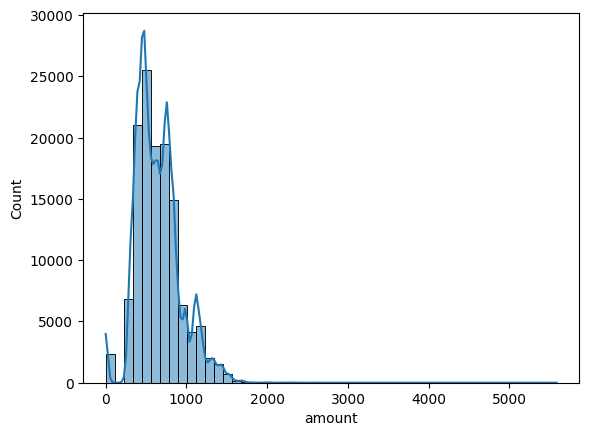

In [29]:
sns.histplot(df['amount'],bins=50,kde=True)

In [30]:
df["category"].value_counts()

category
set              50284
kurta            49877
western dress    15500
top              10622
ethnic dress      1159
blouse             926
bottom             440
saree              164
dupatta              3
Name: count, dtype: int64

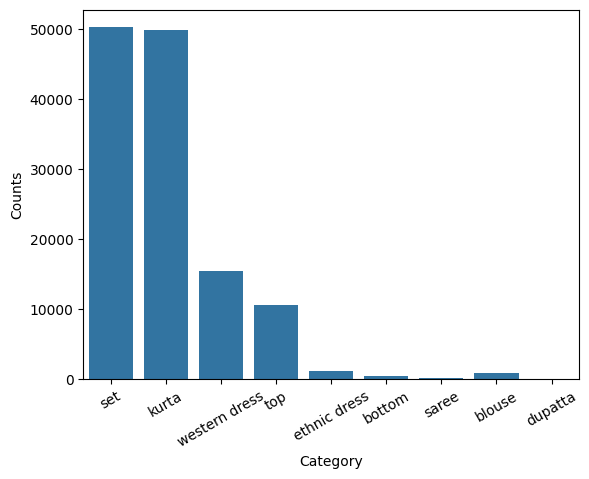

In [31]:
sns.countplot(x="category",data=df)
plt.xticks(rotation=30)
plt.xlabel("Category")
plt.ylabel("Counts")
plt.show()

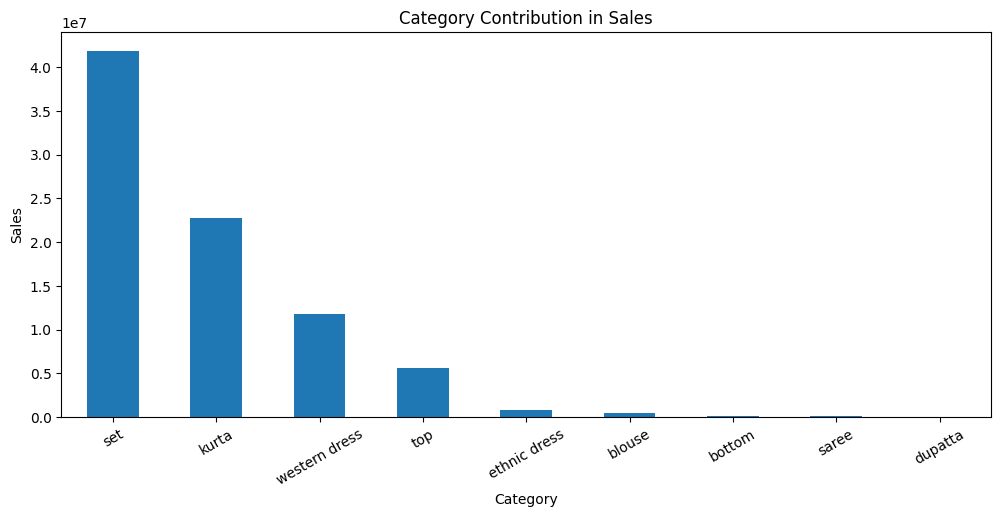

In [32]:
#  Top Sales by category

df.groupby('category')['amount'].sum().sort_values(ascending=False).plot(kind='bar',figsize=(12,5))
plt.xticks(rotation=30)
plt.title("Category Contribution in Sales")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

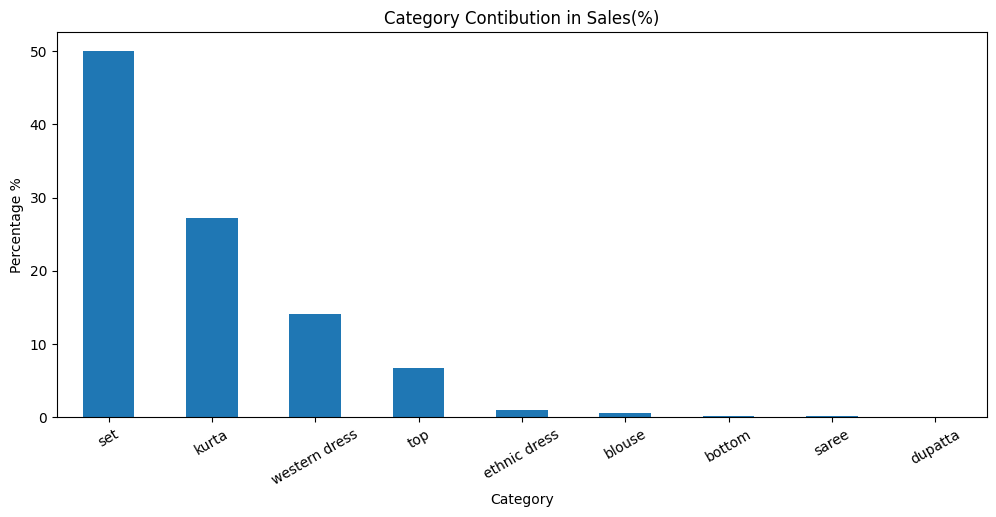

In [33]:
# Sales in Percentage

((df.groupby('category')['amount'].sum()/df['amount'].sum())*100).sort_values(ascending=False).plot(kind="bar",figsize=(12,5))
plt.title("Category Contibution in Sales(%)")
plt.xticks(rotation=30)
plt.xlabel("Category")
plt.ylabel("Percentage %")
plt.show()

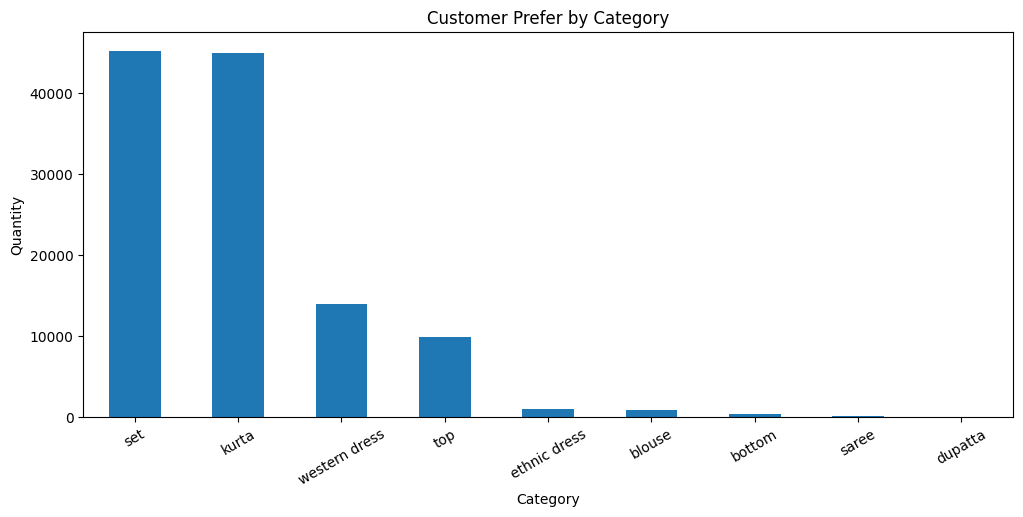

In [34]:
# Customer Prefrence By Category

df.groupby('category')['qty'].sum().sort_values(ascending=False).plot(kind='bar',figsize=(12,5))
plt.title("Customer Prefer by Category")
plt.xticks(rotation=30)
plt.xlabel("Category")
plt.ylabel("Quantity")
plt.show()

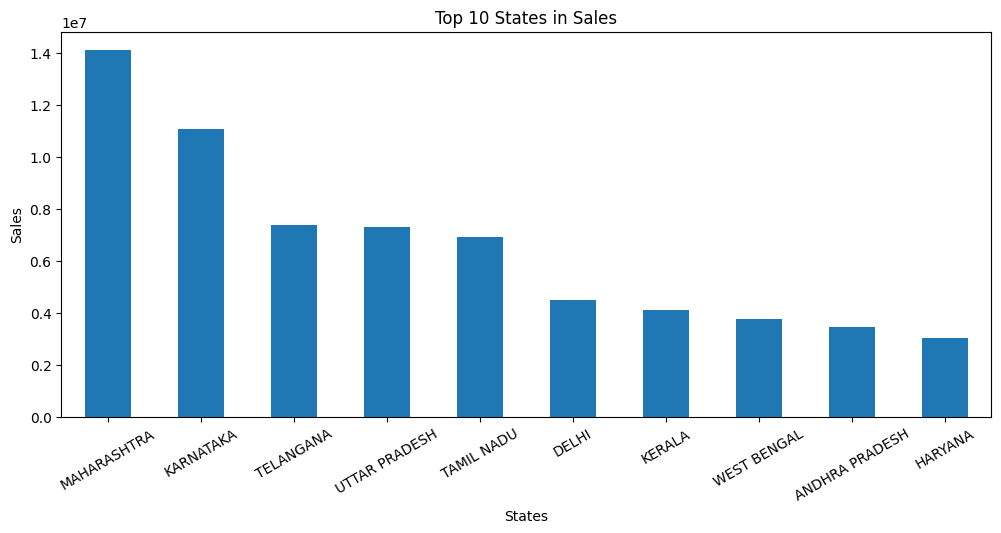

In [35]:
# 
# # Top 10 States in Sales by Amount

df.groupby('ship_state')['amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar',figsize=(12,5))
plt.title("Top 10 States in Sales")
plt.xticks(rotation=30)
plt.xlabel("States")
plt.ylabel("Sales")
plt.show()

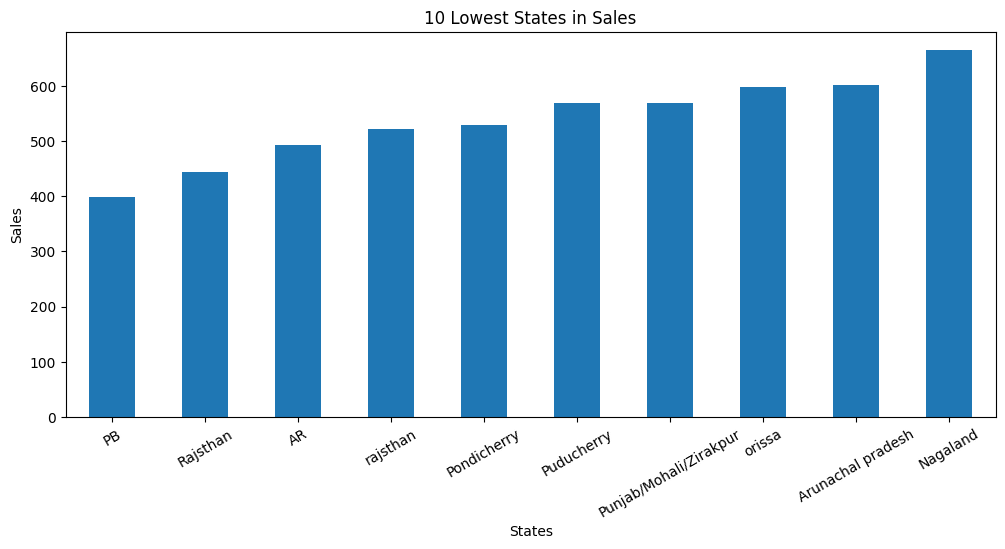

In [36]:
# Lowest 10 States in Sales by Amount

df.groupby('ship_state')['amount'].sum().sort_values(ascending=True).head(10).plot(kind='bar',figsize=(12,5))
plt.title("10 Lowest States in Sales")
plt.xticks(rotation=30)
plt.xlabel("States")
plt.ylabel("Sales")
plt.show()

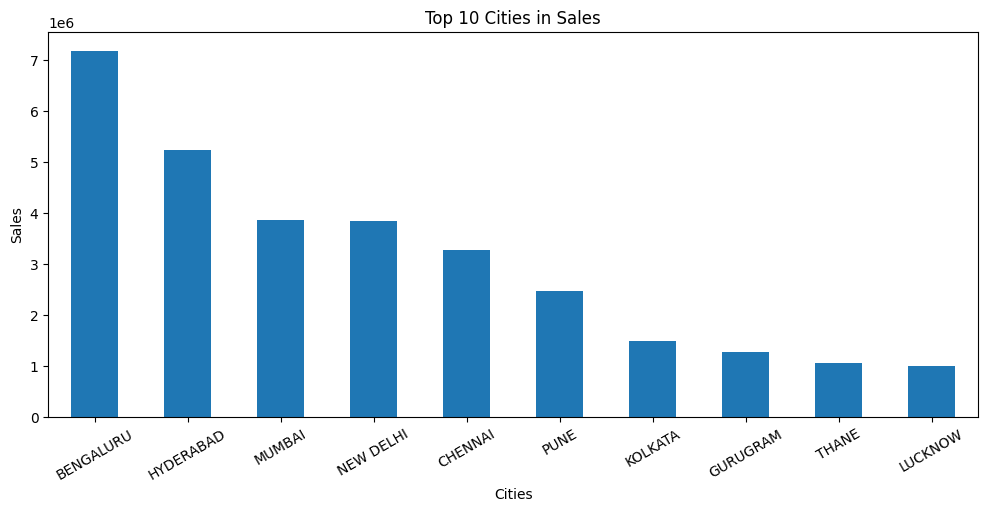

In [37]:
# Top 10 Cities in Sales 

df.groupby('ship_city')['amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar',figsize=(12,5))
plt.title("Top 10 Cities in Sales")
plt.xticks(rotation=30)
plt.xlabel("Cities")
plt.ylabel("Sales")
plt.show()

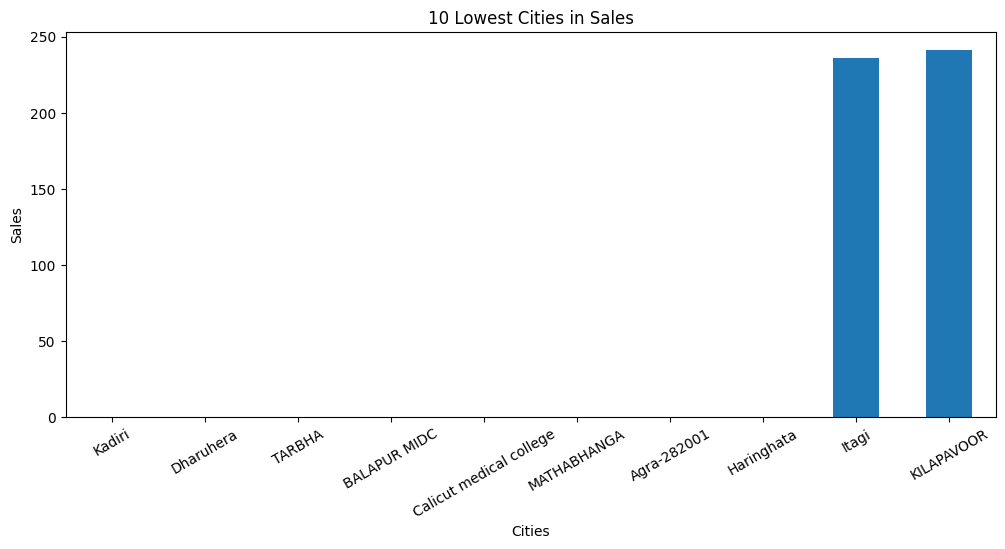

In [38]:
# Lowest 10 Cities i                 n Sales 

df.groupby('ship_city')['amount'].sum().sort_values(ascending=True).head(10).plot(kind='bar',figsize=(12,5))
plt.title("10 Lowest Cities in Sales")
plt.xticks(rotation=30)
plt.xlabel("Cities")
plt.ylabel("Sales")
plt.show()

In [167]:
state_cat = df.pivot_table(
    values='amount',
    index='ship_state',
    columns='category',
    aggfunc='sum'
)

In [168]:
state_cat.idxmax(axis=1)

ship_state
ANDAMAN & NICOBAR               set
ANDHRA PRADESH                  set
APO                             set
AR                              top
ARUNACHAL PRADESH               set
                          ...      
goa                             set
orissa                          set
punjab                          set
rajasthan             western dress
rajsthan                      kurta
Length: 69, dtype: str

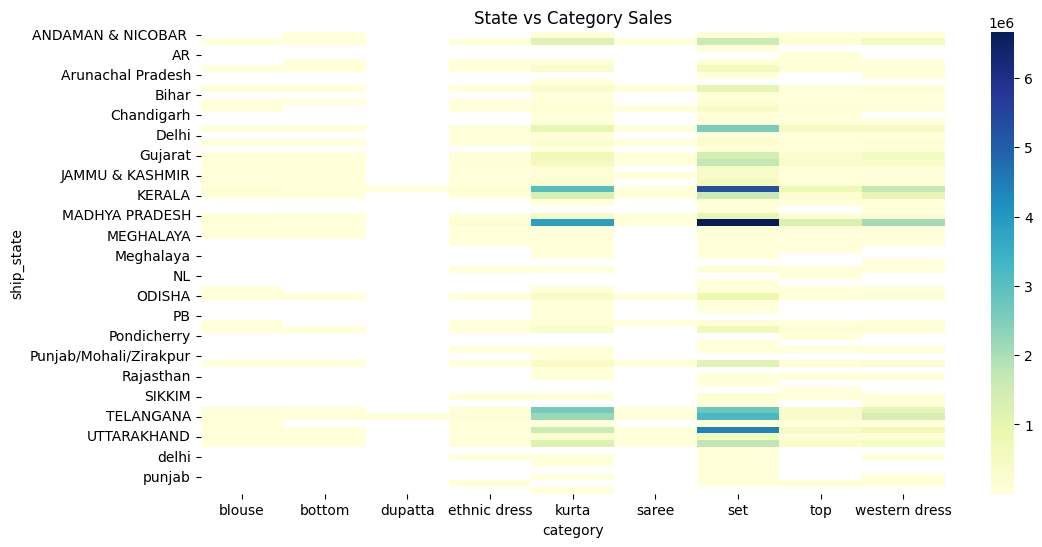

In [169]:
plt.figure(figsize=(12,6))
sns.heatmap(state_cat, cmap='YlGnBu')
plt.title("State vs Category Sales")
plt.show()

In [2]:
df.to_csv("Amazon_Sales.csv",index=False)

NameError: name 'data' is not defined